

# The Epochs data structure: discontinuous data

This tutorial covers the basics of creating and working with :term:`epoched
<epochs>` data. It introduces the :class:`~mne.Epochs` data structure in
detail, including how to load, query, subselect, export, and plot data from an
:class:`~mne.Epochs` object. For more information about visualizing
:class:`~mne.Epochs` objects, see `tut-visualize-epochs`. For info on
creating an :class:`~mne.Epochs` object from (possibly simulated) data in a
:class:`NumPy array <numpy.ndarray>`, see `tut-creating-data-structures`.

As usual we'll start by importing the modules we need:


In [70]:
# Authors: The MNE-Python contributors.
# License: BSD-3-Clause
# Copyright the MNE-Python contributors.

In [71]:
import mne

:class:`~mne.Epochs` objects are a data structure for representing and
analyzing equal-duration chunks of the EEG/MEG signal. :class:`~mne.Epochs`
are most often used to represent data that is time-locked to repeated
experimental events (such as stimulus onsets or subject button presses), but
can also be used for storing sequential or overlapping frames of a continuous
signal (e.g., for analysis of resting-state activity; see
`fixed-length-events`). Inside an :class:`~mne.Epochs` object, the data
are stored in an :class:`array <numpy.ndarray>` of shape ``(n_epochs,
n_channels, n_times)``.

:class:`~mne.Epochs` objects have many similarities with :class:`~mne.io.Raw`
objects, including:

- They can be loaded from and saved to disk in ``.fif`` format, and their
  data can be exported to a :class:`NumPy array <numpy.ndarray>` through the
  :meth:`~mne.Epochs.get_data` method or to a :class:`Pandas DataFrame
  <pandas.DataFrame>` through the :meth:`~mne.Epochs.to_data_frame` method.

- Both :class:`~mne.Epochs` and :class:`~mne.io.Raw` objects support channel
  selection by index or name, including :meth:`~mne.Epochs.pick`,
  :meth:`~mne.Epochs.pick_channels` and :meth:`~mne.Epochs.pick_types`
  methods.

- :term:`SSP projector <projector>` manipulation is possible through
  :meth:`~mne.Epochs.add_proj`, :meth:`~mne.Epochs.del_proj`, and
  :meth:`~mne.Epochs.plot_projs_topomap` methods.

- Both :class:`~mne.Epochs` and :class:`~mne.io.Raw` objects have
  :meth:`~mne.Epochs.copy`, :meth:`~mne.Epochs.crop`,
  :meth:`~mne.Epochs.time_as_index`, :meth:`~mne.Epochs.filter`,
  :meth:`~mne.Epochs.resample`, and :meth:`~mne.Epochs.compute_psd` methods.

- Both :class:`~mne.Epochs` and :class:`~mne.io.Raw` objects have
  :attr:`~mne.Epochs.times`, :attr:`~mne.Epochs.ch_names`,
  :attr:`~mne.Epochs.proj`, and :class:`info <mne.Info>` attributes.

- Both :class:`~mne.Epochs` and :class:`~mne.io.Raw` objects have built-in
  plotting methods :meth:`~mne.Epochs.plot`, and legacy plotting methods
  :meth:`~mne.Epochs.plot_psd` and :meth:`~mne.Epochs.plot_psd_topomap`
  (in new code, PSD plotting is done via the
  :class:`~mne.time_frequency.Spectrum` class).


## Creating Epoched data from a ``Raw`` object

The example dataset we've been using thus far doesn't include pre-epoched
data, so in this section we'll load the continuous data and create epochs
based on the events recorded in the :class:`~mne.io.Raw` object's STIM
channels. As we often do in these tutorials, we'll :meth:`~mne.io.Raw.crop`
the :class:`~mne.io.Raw` data to save memory:



In [72]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(sample_data_raw_file, verbose=False).crop(tmax=60)

As we saw in the `tut-events-vs-annotations` tutorial, we can extract an
events array from :class:`~mne.io.Raw` objects using :func:`mne.find_events`:



In [73]:
events = mne.find_events(raw, stim_channel="STI 014")

Finding events on: STI 014
86 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


> **Note**
>
> We could also have loaded the events from file, using `mne.read_events`:
>
> ```python
> sample_data_events_file = os.path.join(sample_data_folder,
>                                        'MEG', 'sample',
>                                        'sample_audvis_raw-eve.fif')
> events_from_file = mne.read_events(sample_data_events_file)
> ```
>
> See `tut-section-events-io` for more details.

The `mne.io.Raw` object and the events array are the bare minimum needed to create an `mne.Epochs` object, which we create with the `mne.Epochs` class constructor. However, you will almost surely want to change some of the other default parameters. Here we'll change `tmin` and `tmax` (the time relative to each event at which to start and end each epoch). Note also that the `mne.Epochs` constructor accepts parameters `reject` and `flat` for rejecting individual epochs based on signal amplitude. See the `tut-reject-epochs-section` section for examples.


In [74]:
epochs = mne.Epochs(raw, events, tmin=-0.3, tmax=0.7)

Not setting metadata
86 matching events found


Setting baseline interval to [-0.2996928197375818, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated


You'll see from the output that:

- all 320 events were used to create epochs (false, because it was cropped)

- baseline correction was automatically applied (by default, baseline is
  defined as the time span from ``tmin`` to ``0``, but can be customized with
  the ``baseline`` parameter)
  - As EEG is a time-resolving signal, it may often have temporal drifts which are unrelated to our experimental question. Various internal and external sources may cause temporal drifts, which change over time, and also across electrodes. To reduce the effect of such drifts, it is custom to perform a so-called baseline correction. Essentially, this consists of using EEG activity over a baseline period, i.e. before an external event occurs, to correct activity over a post-stimulus interval, i.e. the time after an external event occurs. Various approaches exist for baseline correction. The traditional way is subtracting the mean of a baseline period from every time point of the baseline and post-stimulus interval. In other words, the average voltage values of each electrode are calculated within a time interval and then this average is substracted from that time interval of the signal.




- no additional metadata was provided (see `tut-epochs-metadata` for
  details)

- the projection operators present in the :class:`~mne.io.Raw` file were
  copied over to the :class:`~mne.Epochs` object

If we print the :class:`~mne.Epochs` object, we'll also see a note that the
epochs are not copied into memory by default, and a count of the number of
epochs created for each integer Event ID.



In [75]:
print(epochs)

<Epochs | 86 events (good & bad), -0.3 – 0.699 s (baseline -0.3 – 0 s), ~3.2 MiB, data not loaded,
 '1': 20
 '2': 20
 '3': 20
 '4': 18
 '5': 4
 '32': 4>


Notice that the Event IDs are in quotes; since we didn't provide an event
dictionary, the :class:`mne.Epochs` constructor created one automatically and
used the string representation of the integer Event IDs as the dictionary
keys. This is more clear when viewing the ``event_id`` attribute:



In [76]:
print(epochs.event_id)

{'1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '32': 32}


This time let's pass ``preload=True`` and provide an event dictionary; our
provided dictionary will get stored as the ``event_id`` attribute and will
make referencing events and pooling across event types easier:



In [77]:
event_dict = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
    "face": 5,
    "buttonpress": 32,
}
epochs = mne.Epochs(raw, events, tmin=-0.3, tmax=0.7, event_id=event_dict, preload=True)
print(epochs.event_id)
del raw  # we're done with raw, free up some memory

Not setting metadata
86 matching events found
Setting baseline interval to [-0.2996928197375818, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Loading data for 86 events and 601 original time points ...
1 bad epochs dropped
{'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4, 'face': 5, 'buttonpress': 32}


Notice that the output now mentions "1 bad epoch dropped". In the tutorial
section `tut-reject-epochs-section` we saw how you can specify channel
amplitude criteria for rejecting epochs, but here we haven't specified any
such criteria. In this case, it turns out that the last event was too close
the end of the (cropped) raw file to accommodate our requested ``tmax`` of
0.7 seconds, so the final epoch was dropped because it was too short. Here
are the ``drop_log`` entries for the last 4 epochs (empty lists indicate
epochs that were *not* dropped):



In [78]:
print(epochs.drop_log[-4:])

((), (), (), ('TOO_SHORT',))


> **Note**
>
> If you forget to provide the event dictionary to the `mne.Epochs` constructor, you can add it later by assigning to the `event_id` attribute:
>
> ```python
> epochs.event_id = event_dict
> ```

### Basic visualization of `Epochs` objects

The `mne.Epochs` object can be visualized (and browsed interactively) using its `mne.Epochs.plot` method:


You seem to have overlapping epochs. Some event lines may be duplicated in the plot.


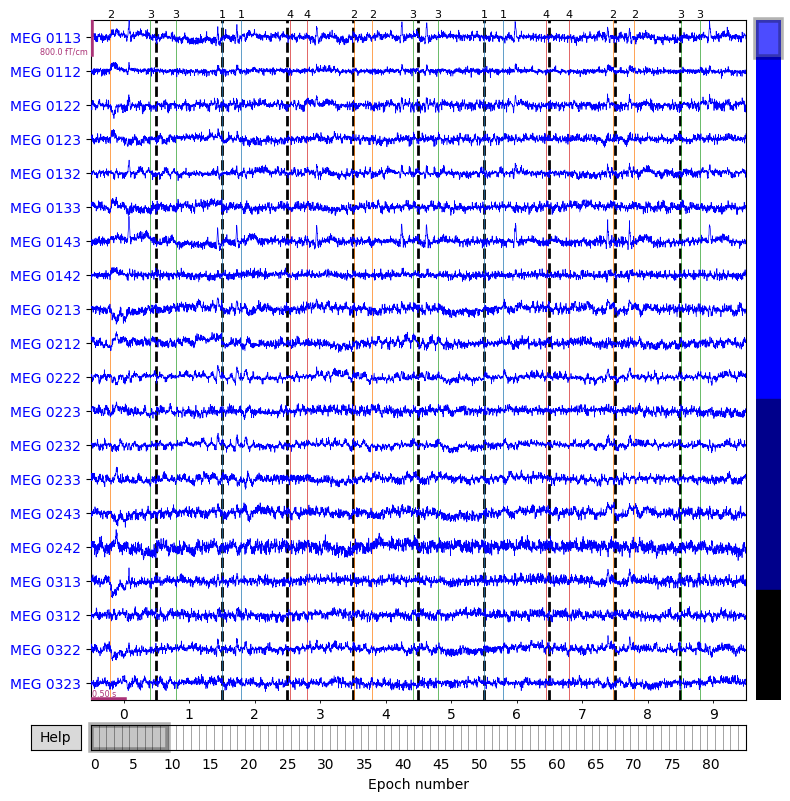

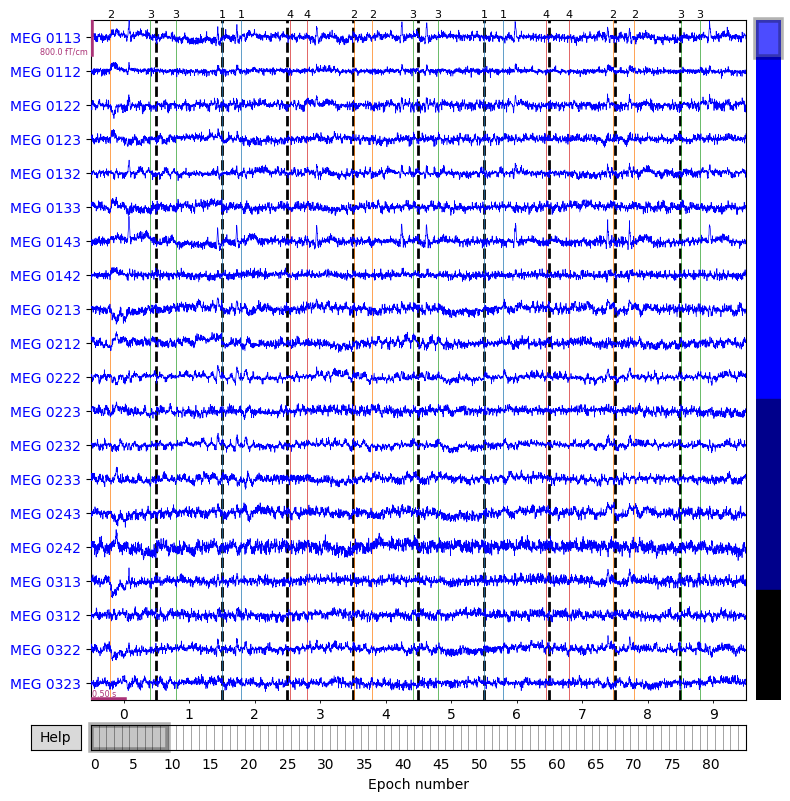

In [79]:
epochs.plot(n_epochs=10, events=True)

Notice that the individual epochs are sequentially numbered along the bottom
axis and are separated by vertical dashed lines.
Epoch plots are interactive (similar to :meth:`raw.plot()
<mne.io.Raw.plot>`) and have many of the same interactive controls as
:class:`~mne.io.Raw` plots. Horizontal and vertical scrollbars allow browsing
through epochs or channels (respectively), and pressing :kbd:`?` when the
plot is focused will show a help screen with all the available controls. See
`tut-visualize-epochs` for more details (as well as other ways of
visualizing epoched data).

- Tracejadas verticais são os separadores de épocas justapostas
- Tracejadas contínuas marcam o tempo dos eventos (onset)


## Subselecting epochs

Now that we have our :class:`~mne.Epochs` object with our descriptive event
labels added, we can subselect epochs easily using square brackets. For
example, we can load all the "catch trials" where the stimulus was a face:



In [80]:
print(epochs["face"])

<Epochs | 4 events (all good), -0.3 – 0.699 s (baseline -0.3 – 0 s), ~10.1 MiB, data loaded,
 'face': 4>


We can also pool across conditions easily, thanks to how MNE-Python handles
the ``/`` character in epoch labels (using what is sometimes called
"tag-based indexing"):



In [81]:
# pool across left + right
print(epochs["auditory"])
assert len(epochs["auditory"]) == (
    len(epochs["auditory/left"]) + len(epochs["auditory/right"])
)
# pool across auditory + visual
print(epochs["left"])
assert len(epochs["left"]) == (
    len(epochs["auditory/left"]) + len(epochs["visual/left"])
)

<Epochs | 40 events (all good), -0.3 – 0.699 s (baseline -0.3 – 0 s), ~72.2 MiB, data loaded,
 'auditory/left': 20
 'auditory/right': 20>
<Epochs | 39 events (all good), -0.3 – 0.699 s (baseline -0.3 – 0 s), ~70.4 MiB, data loaded,
 'auditory/left': 20
 'visual/left': 19>


You can also pool conditions by passing multiple tags as a list. Note that
MNE-Python will not complain if you ask for tags not present in the object,
as long as it can find *some* match: the below example is parsed as
(inclusive) ``'right'`` **or** ``'bottom'``, and you can see from the output
that it selects only ``auditory/right`` and ``visual/right``.



In [82]:
print(epochs[["right", "bottom"]])

<Epochs | 38 events (all good), -0.3 – 0.699 s (baseline -0.3 – 0 s), ~68.7 MiB, data loaded,
 'auditory/right': 20
 'visual/right': 18>


However, if no match is found, an error is returned:



In [83]:
try:
    print(epochs[["top", "bottom"]])
except KeyError:
    print("Tag-based selection with no matches raises a KeyError!")

Tag-based selection with no matches raises a KeyError!


### Selecting epochs by index

:class:`~mne.Epochs` objects can also be indexed with integers, :term:`slices
<slice>`, or lists of integers. This method of selection ignores event
labels, so if you want the first 10 epochs of a particular type, you can
select the type first, then use integers or slices:



In [102]:
print(epochs[:10])  # epochs 0-9
print(epochs[1:8:2])  # epochs 1, 3, 5, 7


print(epochs["buttonpress"][:4])  # first 4 "buttonpress" epochs
print(epochs["buttonpress"][[0, 1, 2, 3]])  # same as previous line

<Epochs | 10 events (all good), -0.3 – 0.699 s (baseline -0.3 – 0 s), ~20.4 MiB, data loaded,
 'auditory/left': 2
 'auditory/right': 3
 'visual/left': 3
 'visual/right': 2>
<Epochs | 4 events (all good), -0.3 – 0.699 s (baseline -0.3 – 0 s), ~10.1 MiB, data loaded,
 'visual/left': 2
 'visual/right': 2>
<Epochs | 4 events (all good), -0.3 – 0.699 s (baseline -0.3 – 0 s), ~10.1 MiB, data loaded,
 'buttonpress': 4>
<Epochs | 4 events (all good), -0.3 – 0.699 s (baseline -0.3 – 0 s), ~10.1 MiB, data loaded,
 'buttonpress': 4>


### Selecting, dropping, and reordering channels

You can use the :meth:`~mne.Epochs.pick`, :meth:`~mne.Epochs.pick_channels`,
:meth:`~mne.Epochs.pick_types`, and :meth:`~mne.Epochs.drop_channels` methods
to modify which channels are included in an :class:`~mne.Epochs` object. You
can also use :meth:`~mne.Epochs.reorder_channels` for this purpose; any
channel names not provided to :meth:`~mne.Epochs.reorder_channels` will be
dropped. Note that these *channel* selection methods modify the object
in-place (unlike the square-bracket indexing to select *epochs* seen above)
so in interactive/exploratory sessions you may want to create a
:meth:`~mne.Epochs.copy` first.



In [85]:
epochs_eeg = epochs.copy().pick(picks="eeg")
print(epochs_eeg.ch_names)

new_order = ["EEG 002", "STI 014", "EOG 061", "MEG 2521"]
epochs_subset = epochs.copy().reorder_channels(new_order)
print(epochs_subset.ch_names)

['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008', 'EEG 009', 'EEG 010', 'EEG 011', 'EEG 012', 'EEG 013', 'EEG 014', 'EEG 015', 'EEG 016', 'EEG 017', 'EEG 018', 'EEG 019', 'EEG 020', 'EEG 021', 'EEG 022', 'EEG 023', 'EEG 024', 'EEG 025', 'EEG 026', 'EEG 027', 'EEG 028', 'EEG 029', 'EEG 030', 'EEG 031', 'EEG 032', 'EEG 033', 'EEG 034', 'EEG 035', 'EEG 036', 'EEG 037', 'EEG 038', 'EEG 039', 'EEG 040', 'EEG 041', 'EEG 042', 'EEG 043', 'EEG 044', 'EEG 045', 'EEG 046', 'EEG 047', 'EEG 048', 'EEG 049', 'EEG 050', 'EEG 051', 'EEG 052', 'EEG 053', 'EEG 054', 'EEG 055', 'EEG 056', 'EEG 057', 'EEG 058', 'EEG 059', 'EEG 060']
['EEG 002', 'STI 014', 'EOG 061', 'MEG 2521']


In [86]:
del epochs_eeg, epochs_subset

### Changing channel name and type

You can change the name or type of a channel using
:meth:`~mne.Epochs.rename_channels` or :meth:`~mne.Epochs.set_channel_types`.
Both methods take :class:`dictionaries <dict>` where the keys are existing
channel names, and the values are the new name (or type) for that channel.
Existing channels that are not in the dictionary will be unchanged.



In [87]:
epochs.rename_channels({"EOG 061": "BlinkChannel"})

epochs.set_channel_types({"EEG 060": "ecg"})
print(list(zip(epochs.ch_names, epochs.get_channel_types()))[-4:])

'''

zip(..., ...): A função zip pega o primeiro elemento da lista de nomes e o primeiro da 
lista de tipos e cria uma tupla (nome, tipo). Ela faz isso para o segundo elemento, o 
terceiro, e assim por diante, "costurando" as duas listas.

list(...): O zip em Python retorna um iterador (que não mostra os dados diretamente se
você der um print). A função list() converte esse iterador em uma lista real de tuplas
para que possa ser fatiada e visualizada.

'''

[('EEG 058', 'eeg'), ('EEG 059', 'eeg'), ('EEG 060', 'ecg'), ('BlinkChannel', 'eog')]


'\n\nzip(..., ...): A função zip pega o primeiro elemento da lista de nomes e o primeiro da \nlista de tipos e cria uma tupla (nome, tipo). Ela faz isso para o segundo elemento, o \nterceiro, e assim por diante, "costurando" as duas listas.\n\nlist(...): O zip em Python retorna um iterador (que não mostra os dados diretamente se\nvocê der um print). A função list() converte esse iterador em uma lista real de tuplas\npara que possa ser fatiada e visualizada.\n\n'

In [88]:
# let's set them back to the correct values before moving on
epochs.rename_channels({"BlinkChannel": "EOG 061"})
epochs.set_channel_types({"EEG 060": "eeg"})

<Epochs | 85 events (all good), -0.3 – 0.699 s (baseline -0.3 – 0 s), ~149.7 MiB, data loaded,
 'auditory/left': 20
 'auditory/right': 20
 'visual/left': 19
 'visual/right': 18
 'face': 4
 'buttonpress': 4>

### Selection in the time domain

To change the temporal extent of the :class:`~mne.Epochs`, you can use the
:meth:`~mne.Epochs.crop` method:



In [89]:
shorter_epochs = epochs.copy().crop(tmin=-0.1, tmax=0.1, include_tmax=True)

for name, obj in dict(Original=epochs, Cropped=shorter_epochs).items():
    print(f"{name} epochs has {obj.get_data(copy=False).shape[-1]} time samples")

Original epochs has 601 time samples
Cropped epochs has 121 time samples


Cropping removed part of the baseline. When printing the
cropped :class:`~mne.Epochs`, MNE-Python will inform you about the time
period that was originally used to perform baseline correction by displaying
the string "baseline period cropped after baseline correction":



In [90]:
print(shorter_epochs)

<Epochs | 85 events (all good), -0.1 – 0.1 s (baseline -0.3 – 0 s (baseline period was cropped after baseline correction)), ~32.7 MiB, data loaded,
 'auditory/left': 20
 'auditory/right': 20
 'visual/left': 19
 'visual/right': 18
 'face': 4
 'buttonpress': 4>


However, if you wanted to *expand* the time domain of an :class:`~mne.Epochs`
object, you would need to go back to the :class:`~mne.io.Raw` data and
recreate the :class:`~mne.Epochs` with different values for ``tmin`` and/or
``tmax``.

It is also possible to change the "zero point" that defines the time values
in an :class:`~mne.Epochs` object, with the :meth:`~mne.Epochs.shift_time`
method. :meth:`~mne.Epochs.shift_time` allows shifting times relative to the
current values, or specifying a fixed time to set as the new time value of
the first sample (deriving the new time values of subsequent samples based on
the :class:`~mne.Epochs` object's sampling frequency).



In [91]:
# shift times so that first sample of each epoch is at time zero
later_epochs = epochs.copy().shift_time(tshift=0.0, relative=False)
print(later_epochs.times[:3])

# shift times by a relative amount
later_epochs.shift_time(tshift=-7, relative=True)
print(later_epochs.times[:3])

[0.         0.00166496 0.00332992]
[-7.         -6.99833504 -6.99667008]


In [92]:
del shorter_epochs, later_epochs

Note that although time shifting respects the sampling frequency (the spacing
between samples), it does not enforce the assumption that there is a sample
occurring at exactly time=0.


### Extracting data in other forms

The :meth:`~mne.Epochs.get_data` method returns the epoched data as a
:class:`NumPy array <numpy.ndarray>`, of shape ``(n_epochs, n_channels,
n_times)``; an optional ``picks`` parameter selects a subset of channels by
index, name, or type:



In [104]:
eog_data = epochs.get_data(picks="EOG 061")
meg_data = epochs.get_data(picks=["mag", "grad"])
channel_4_6_8 = epochs.get_data(picks=slice(4, 9, 2))

print (  slice (4, 9, 2)   )
print ( type ( slice (4, 9, 2) )  ) ## start, stop, steps

for name, arr in dict(EOG=eog_data, MEG=meg_data, Slice=channel_4_6_8).items():
    print(f"{name} contains {arr.shape[1]} channels")

slice(4, 9, 2)
<class 'slice'>
EOG contains 1 channels
MEG contains 305 channels
Slice contains 3 channels


Note that if your analysis requires repeatedly extracting single epochs from
an :class:`~mne.Epochs` object, ``epochs.get_data(item=2)`` will be much
faster than ``epochs[2].get_data()``, because it avoids the step of
subsetting the :class:`~mne.Epochs` object first.

        - In the context of epochs.get_data(item=2), the item parameter represents the index of the epoch within the Epochs object that you want to retrieve. Since Python is 0-indexed, item=2 refers to the 3rd epoch stored in that object. So is epochs[2]


You can also export :class:`~mne.Epochs` data to :class:`Pandas DataFrames
<pandas.DataFrame>`. Here, the :class:`~pandas.DataFrame` index will be
constructed by converting the time of each sample into milliseconds and
rounding it to the nearest integer, and combining it with the event types and
epoch numbers to form a hierarchical :class:`~pandas.MultiIndex`. Each
channel will appear in a separate column. Then you can use any of Pandas'
tools for grouping and aggregating data; for example, here we select any
epochs numbered 10 or less from the ``auditory/left`` condition, and extract
times between 100 and 107 ms on channels ``EEG 056`` through ``EEG 058``
(note that slice indexing within Pandas' :obj:`~pandas.DataFrame.loc` is
inclusive of the endpoint):



### Estrutura do DataFrame (MNE-Python)

Ao converter objetos `Epochs` para DataFrame usando `to_data_frame(index=["condition", "epoch", "time"])`, a estrutura resultante é uma tabela bidimensional organizada da seguinte forma:

- **Linhas (Índice/Index):** Representam o **"Quem e Quando"**.
  - Utiliza um *MultiIndex* (índice hierárquico) composto por:
    1. `condition`: O tipo de estímulo (ex: "auditory/left").
    2. `epoch`: O ID da tentativa (trial).
    3. `time`: O instante exato da gravação (em ms ou segundos).
  - Cada linha é uma observação única de um momento específico no tempo.

- **Colunas:** Representam o **"O Quê"** (Variáveis).
  - Cada coluna corresponde a um **Canal/Sensor** (ex: `MEG 0123`, `EEG 056`).
  - O valor na célula é a amplitude do sinal naquele instante.

- **Visualização no Console:**
  - Se o DataFrame possuir muitas colunas (muitos canais), o `print()` do Pandas "quebra" a tabela visualmente em vários blocos para caber na tela. Isso é apenas estético; a estrutura interna dos dados permanece uma tabela única e contínua (2D).

#### Exemplo Visual

```python
# Exemplo de estrutura simplificada
# Index (Linhas)                     | Colunas (Canais)
# condition      epoch   time        | MEG 01   EEG 01 ...
# auditory/left  0       -0.200      | 5.4e-12  -3.2e-6
# auditory/left  0       -0.199      | 5.5e-12  -3.1e-6


In [ ]:
df = epochs.to_data_frame(index=["condition", "epoch", "time"])
print ( df.head() )

df.sort_index(inplace=True)
print(df.loc[("auditory/left", slice(0, 10), slice(100, 107)), "EEG 056":"EEG 058"])
print(df.shape) ## Isto prova que a tabela é 2D


del df

channel                          MEG 0113   MEG 0112    MEG 0111   MEG 0122  \
condition      epoch time                                                     
auditory/right 0     -0.299693 -67.984397 -24.028968   98.911968  49.016964   
                     -0.298028 -58.340843 -14.385413   52.987849  10.442744   
                     -0.296363 -77.627952  14.545251  101.186224 -47.418584   
                     -0.294698 -10.123069  24.188806  170.431668 -66.705694   
                     -0.293033  18.807596  43.475916  196.893516  -8.844365   

channel                          MEG 0123    MEG 0121   MEG 0132    MEG 0133  \
condition      epoch time                                                      
auditory/right 0     -0.299693  53.066191  156.152327   4.422183   10.336186   
                     -0.298028  14.491972  114.725693  -5.221372   10.336186   
                     -0.296363  33.779081  114.847401 -24.508482   48.910405   
                     -0.294698  53.066191  150

See the `tut-epochs-dataframe` tutorial for many more examples of the
:meth:`~mne.Epochs.to_data_frame` method.


## Loading and saving ``Epochs`` objects to disk

:class:`~mne.Epochs` objects can be loaded and saved in the ``.fif`` format
just like :class:`~mne.io.Raw` objects, using the :func:`mne.read_epochs`
function and the :meth:`~mne.Epochs.save` method. Functions are also
available for loading data that was epoched outside of MNE-Python, such as
:func:`mne.read_epochs_eeglab` and :func:`mne.read_epochs_kit`.



In [95]:
epochs.save("saved-audiovisual-epo.fif", overwrite=True)
epochs_from_file = mne.read_epochs("saved-audiovisual-epo.fif", preload=False)

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Reading c:\Users\peuqu\OneDrive\Desktop\IC Harlei\WorkSpace\TUTORIALS\saved-audiovisual-epo.fif ...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
    Found the data of interest:
        t =    -299.69 ...     699.28 ms
        0 CTF compensation matrices available
Not setting metadata
85 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 3)
3 projection items activated


The MNE-Python naming convention for epochs files is that the file basename
(the part before the ``.fif`` or ``.fif.gz`` extension) should end with
``-epo`` or ``_epo``, and a warning will be issued if the filename you
provide does not adhere to that convention.

As a final note, be aware that the class of the epochs object is different
when epochs are loaded from disk rather than generated from a
:class:`~mne.io.Raw` object:



In [96]:
print(type(epochs))
print(type(epochs_from_file))

<class 'mne.epochs.Epochs'>
<class 'mne.epochs.EpochsFIF'>


In almost all cases this will not require changing anything about your code.
However, if you need to do type checking on epochs objects, you can test
against the base class that these classes are derived from:



In [97]:
print(
    all(
        [
            isinstance(epochs, mne.BaseEpochs),
            isinstance(epochs_from_file, mne.BaseEpochs),
        ]
    )
)

True


## Iterating over ``Epochs``

Iterating over an :class:`~mne.Epochs` object will yield :class:`arrays
<numpy.ndarray>` rather than single-trial :class:`~mne.Epochs` objects:



In [98]:
for epoch in epochs[:3]:
    print(type(epoch))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


If you want to iterate over :class:`~mne.Epochs` objects, you can use an
integer index as the iterator:



In [99]:
for index in range(3):
    print(type(epochs[index]))

<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
